# Option Pricing Market Validation Notebook

This notebook performs a cross-sectional market validation using current option market quotes from `yfinance`.

The validation uses the current stock price, the daily SOFR risk-free rate, and volatility estimated from the past 3 years of stock-price history. Model prices are then compared with observed option prices across strikes and maturities.

In this notebook:
- `CRR American` is used as the American-option pricing model.
- `CRR European` is used as a binomial European benchmark.
- `BSM European` is used as the closed-form European benchmark.

The goal is to evaluate how closely each model aligns with real market option prices in the current cross section.

## 1. Notebook Setup

Make the local package importable in JupyterLab and refresh cached modules so the notebook always uses the latest code.

In [3]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

for module_name in list(sys.modules):
    if module_name == "option_pricing" or module_name.startswith("option_pricing."):
        sys.modules.pop(module_name)
importlib.invalidate_caches()

src_path

PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/src')

## 2. Imports and Validation Configuration

Set the ticker, build the historical input window, and define simple filters for the option contracts used in the comparison.

In [5]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from option_pricing.config import get_project_paths
from option_pricing.data_helper import fetch_latest_sofr_rate, get_price_data, remove_existing_files, save_csv, validate_ticker
from option_pricing.pricing_model import bsm_price, crr_binomial_price
from option_pricing.volatility import realized_volatility

paths = get_project_paths()
ticker = "AAPL"
history_start_date = (pd.Timestamp.today().normalize() - pd.DateOffset(years=3)).date().isoformat()
max_contracts_per_side = 8
moneyness_band = 0.12

# Keep only the latest validation outputs, even if the ticker changes.
remove_existing_files(paths.processed_data, "*_current_validation_inputs.csv")
remove_existing_files(paths.tables, "*_current_market_validation*.csv")
remove_existing_files(paths.figures, "*_current_market_validation_*.png")

assert validate_ticker(ticker), f"Ticker {ticker} is not available."
paths

ProjectPaths(root=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)'), data=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/data'), raw_data=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/data/raw'), processed_data=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/data/processed'), docs=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/docs'), notebooks=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/notebooks'), outputs=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/outputs'), figures=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/outputs/figures'), tables=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/outputs/tables'))

## 3. Build the Current Information Set

Use the current stock price, the latest published SOFR observation, and volatility estimated from the past 3 years of daily prices.

In [7]:
price_history = get_price_data(ticker=ticker, start=history_start_date, end=date.today().isoformat())
evaluation_date = pd.Timestamp(price_history["date"].max())
spot_price = float(price_history["adj_close"].iloc[-1])
sigma_annual = realized_volatility(price_history, price_column="adj_close")
sofr_info = fetch_latest_sofr_rate()
risk_free_rate = sofr_info.rate_decimal

current_inputs = pd.DataFrame(
    {
        "ticker": [ticker],
        "evaluation_date": [evaluation_date.date().isoformat()],
        "history_start_date": [history_start_date],
        "spot_price": [spot_price],
        "annualized_sigma": [sigma_annual],
        "sofr_observation_date": [sofr_info.observation_date],
        "sofr_percent": [sofr_info.rate_percent],
        "risk_free_rate": [risk_free_rate],
    }
)

save_csv(current_inputs, paths.processed_data / f"{ticker}_current_validation_inputs.csv")
current_inputs

,ticker,evaluation_date,history_start_date,spot_price,annualized_sigma,sofr_observation_date,sofr_percent,risk_free_rate
0,AAPL,2026-04-01,2023-04-01,254.639999,0.255648,2026-03-31,3.68,0.0368


## 4. Download the Current Option Chain

Fetch the current option chain from `yfinance`, keep future expirations, and select liquid contracts near the current stock price.

For market comparison, the notebook uses the bid-ask midpoint when available and falls back to `lastPrice` if needed.

In [9]:
ticker_obj = yf.Ticker(ticker)
expiration_strings = ticker_obj.options
expiration_dates = [pd.Timestamp(exp) for exp in expiration_strings]
eligible_expirations = [exp for exp in expiration_dates if exp > evaluation_date]
selected_expirations = eligible_expirations[:3]

def prepare_option_side(frame: pd.DataFrame, side_label: str, expiration_date: pd.Timestamp) -> pd.DataFrame:
    side = frame.copy()
    side["option_side"] = side_label
    side["expiration"] = expiration_date
    side["mid_price"] = (side["bid"].fillna(0.0) + side["ask"].fillna(0.0)) / 2.0
    side["market_price"] = np.where(side["mid_price"] > 0, side["mid_price"], side["lastPrice"])
    side["moneyness_gap"] = (side["strike"] - spot_price).abs() / spot_price
    side = side[side["market_price"] > 0].copy()
    side = side[side["moneyness_gap"] <= moneyness_band].copy()
    side = side.sort_values(["moneyness_gap", "openInterest", "volume"], ascending=[True, False, False])
    return side.head(max_contracts_per_side)

selected_frames = []
for expiration_date in selected_expirations:
    chain = ticker_obj.option_chain(expiration_date.strftime("%Y-%m-%d"))
    selected_frames.append(prepare_option_side(chain.calls, "call", expiration_date))
    selected_frames.append(prepare_option_side(chain.puts, "put", expiration_date))

validation_contracts = pd.concat(selected_frames, ignore_index=True)
validation_contracts = validation_contracts.drop_duplicates(subset=["contractSymbol"]).reset_index(drop=True)

validation_contracts[["contractSymbol", "option_side", "expiration", "strike", "market_price", "bid", "ask", "lastPrice", "volume", "openInterest"]].head(20)

,contractSymbol,option_side,expiration,strike,market_price,bid,ask,lastPrice,volume,openInterest
0,AAPL260402C00255000,call,2026-04-02,255.0,1.175,1.15,1.20,1.20,9932.0,14924
1,AAPL260402C00252500,call,2026-04-02,252.5,2.605,2.57,2.64,2.75,3080.0,4568
2,AAPL260402C00257500,call,2026-04-02,257.5,0.400,0.39,0.41,0.40,6687.0,13323
3,AAPL260402C00250000,call,2026-04-02,250.0,4.625,4.45,4.80,4.50,2060.0,6673
4,AAPL260402C00260000,call,2026-04-02,260.0,0.140,0.13,0.15,0.14,4213.0,12213
5,AAPL260402C00247500,call,2026-04-02,247.5,6.975,6.65,7.30,6.94,103.0,1698
6,AAPL260402C00262500,call,2026-04-02,262.5,0.055,0.05,0.06,0.06,1736.0,11821
7,AAPL260402C00245000,call,2026-04-02,245.0,9.525,9.05,10.00,9.40,229.0,3114
8,AAPL260402P00255000,put,2026-04-02,255.0,2.115,2.07,2.16,2.10,5029.0,2250
9,AAPL260402P00252500,put,2026-04-02,252.5,1.015,0.99,1.04,1.01,8553.0,5957


## 5. Price the Selected Contracts

Price each contract with three model outputs:
- `CRR American`
- `CRR European`
- `BSM European`

This keeps the comparison aligned with the different modeling assumptions.

In [11]:
validation_rows = []

for _, contract in validation_contracts.iterrows():
    maturity_days = max(int(np.busday_count(evaluation_date.date(), contract["expiration"].date())), 1)
    strike = float(contract["strike"])
    option_side = contract["option_side"]
    market_price = float(contract["market_price"])

    crr_american = crr_binomial_price(
        spot_price=spot_price,
        strike=strike,
        risk_free_rate=risk_free_rate,
        sigma_annual=sigma_annual,
        maturity_days=maturity_days,
        option_type=option_side,
        exercise_style="american",
    )
    crr_european = crr_binomial_price(
        spot_price=spot_price,
        strike=strike,
        risk_free_rate=risk_free_rate,
        sigma_annual=sigma_annual,
        maturity_days=maturity_days,
        option_type=option_side,
        exercise_style="european",
    )
    bsm_european = bsm_price(
        spot_price=spot_price,
        strike=strike,
        risk_free_rate=risk_free_rate,
        sigma_annual=sigma_annual,
        maturity_days=maturity_days,
        option_type=option_side,
    )

    validation_rows.append(
        {
            "ticker": ticker,
            "evaluation_date": evaluation_date.date().isoformat(),
            "contractSymbol": contract["contractSymbol"],
            "option_side": option_side,
            "expiration": contract["expiration"].date().isoformat(),
            "maturity_days": maturity_days,
            "strike": strike,
            "market_price": market_price,
            "crr_american_price": crr_american,
            "crr_european_price": crr_european,
            "bsm_european_price": bsm_european,
            "crr_american_abs_error": abs(crr_american - market_price),
            "crr_european_abs_error": abs(crr_european - market_price),
            "bsm_european_abs_error": abs(bsm_european - market_price),
            "crr_american_pct_error": abs(crr_american - market_price) / market_price,
            "crr_european_pct_error": abs(crr_european - market_price) / market_price,
            "bsm_european_pct_error": abs(bsm_european - market_price) / market_price,
        }
    )

validation_results = pd.DataFrame(validation_rows)
validation_results.head(20)

,ticker,evaluation_date,contractSymbol,option_side,expiration,maturity_days,strike,market_price,crr_american_price,crr_european_price,bsm_european_price,crr_american_abs_error,crr_european_abs_error,bsm_european_abs_error,crr_american_pct_error,crr_european_pct_error,bsm_european_pct_error
0,AAPL,2026-04-01,AAPL260402C00255000,call,2026-04-02,1,255.0,1.175,1.888643,1.888643,1.480683,0.713643,0.713643,0.305683,0.607356,0.607356,0.260156
1,AAPL,2026-04-01,AAPL260402C00252500,call,2026-04-02,1,252.5,2.605,3.139731,3.139731,2.943564,0.534731,0.534731,0.338564,0.205271,0.205271,0.129967
2,AAPL,2026-04-01,AAPL260402C00257500,call,2026-04-02,1,257.5,0.400,0.637556,0.637556,0.604800,0.237556,0.237556,0.204800,0.593890,0.593890,0.511999
3,AAPL,2026-04-01,AAPL260402C00250000,call,2026-04-02,1,250.0,4.625,4.676505,4.676505,4.928323,0.051505,0.051505,0.303323,0.011136,0.011136,0.065583
4,AAPL,2026-04-01,AAPL260402C00260000,call,2026-04-02,1,260.0,0.140,0.000000,0.000000,0.194971,0.140000,0.140000,0.054971,1.000000,1.000000,0.392651
5,AAPL,2026-04-01,AAPL260402C00247500,call,2026-04-02,1,247.5,6.975,7.176140,7.176140,7.237571,0.201140,0.201140,0.262571,0.028837,0.028837,0.037645
6,AAPL,2026-04-01,AAPL260402C00262500,call,2026-04-02,1,262.5,0.055,0.000000,0.000000,0.048638,0.055000,0.055000,0.006362,1.000000,1.000000,0.115671
7,AAPL,2026-04-01,AAPL260402C00245000,call,2026-04-02,1,245.0,9.525,9.675775,9.675775,9.686537,0.150775,0.150775,0.161537,0.015829,0.015829,0.016959
8,AAPL,2026-04-01,AAPL260402P00255000,put,2026-04-02,1,255.0,2.115,2.211409,2.211409,1.803448,0.096409,0.096409,0.311552,0.045583,0.045583,0.147306
9,AAPL,2026-04-01,AAPL260402P00252500,put,2026-04-02,1,252.5,1.015,0.962861,0.962861,0.766694,0.052139,0.052139,0.248306,0.051368,0.051368,0.244636


## 6. Summarize Pricing Error

Compute average error metrics across the selected contracts so the three model variants can be compared side by side.

In [13]:
accuracy_summary = pd.DataFrame(
    {
        "model": ["CRR American", "CRR European", "BSM European"],
        "mean_abs_error": [
            validation_results["crr_american_abs_error"].mean(),
            validation_results["crr_european_abs_error"].mean(),
            validation_results["bsm_european_abs_error"].mean(),
        ],
        "rmse": [
            float(np.sqrt((validation_results["crr_american_abs_error"] ** 2).mean())),
            float(np.sqrt((validation_results["crr_european_abs_error"] ** 2).mean())),
            float(np.sqrt((validation_results["bsm_european_abs_error"] ** 2).mean())),
        ],
        "mean_pct_error": [
            validation_results["crr_american_pct_error"].mean(),
            validation_results["crr_european_pct_error"].mean(),
            validation_results["bsm_european_pct_error"].mean(),
        ],
    }
)

save_csv(validation_results, paths.tables / f"{ticker}_current_market_validation_contracts.csv")
save_csv(accuracy_summary, paths.tables / f"{ticker}_current_market_validation_summary.csv")
accuracy_summary

,model,mean_abs_error,rmse,mean_pct_error
0,CRR American,0.320135,0.394719,0.345132
1,CRR European,0.322959,0.396587,0.345317
2,BSM European,0.285464,0.344214,0.274334


## 7. Visualization: Market Price vs Model Price

Plot each model against observed market prices. The 45-degree line represents perfect pricing accuracy.

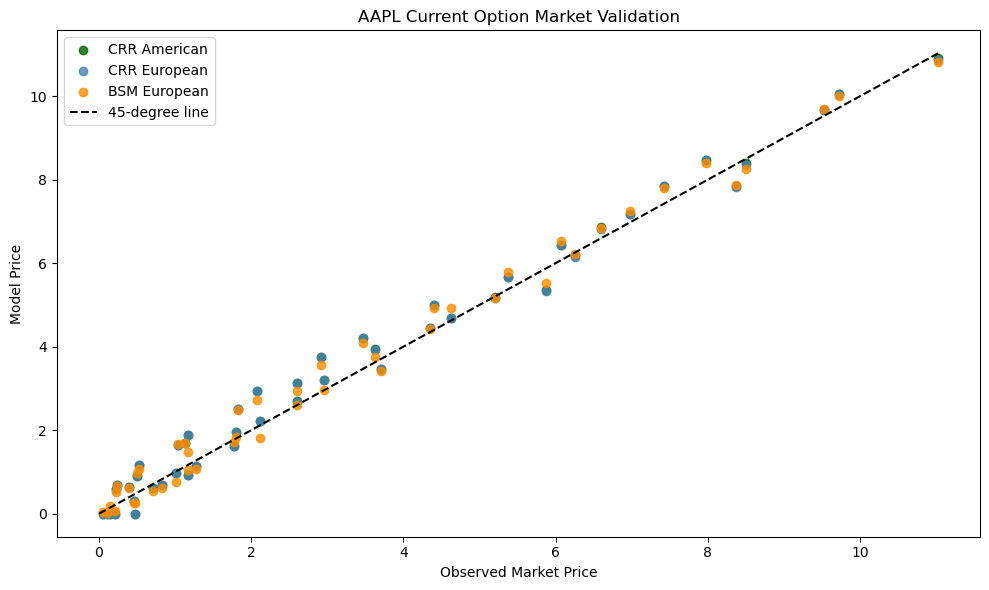

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(validation_results["market_price"], validation_results["crr_american_price"], label="CRR American", color="darkgreen", alpha=0.8)
plt.scatter(validation_results["market_price"], validation_results["crr_european_price"], label="CRR European", color="steelblue", alpha=0.8)
plt.scatter(validation_results["market_price"], validation_results["bsm_european_price"], label="BSM European", color="darkorange", alpha=0.8)
max_price = float(validation_results[["market_price", "crr_american_price", "crr_european_price", "bsm_european_price"]].max().max())
plt.plot([0, max_price], [0, max_price], linestyle="--", color="black", label="45-degree line")
plt.xlabel("Observed Market Price")
plt.ylabel("Model Price")
plt.title(f"{ticker} Current Option Market Validation")
plt.legend()
plt.tight_layout()

plt.savefig(paths.figures / f"{ticker}_current_market_validation_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Visualization: Average Absolute Error by Model

Compare the average absolute pricing error across the three model variants.

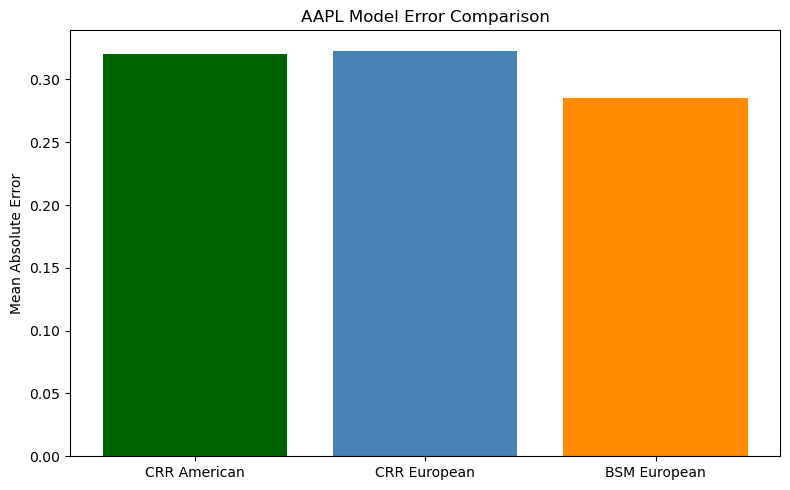

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(accuracy_summary["model"], accuracy_summary["mean_abs_error"], color=["darkgreen", "steelblue", "darkorange"])
plt.ylabel("Mean Absolute Error")
plt.title(f"{ticker} Model Error Comparison")
plt.tight_layout()

plt.savefig(paths.figures / f"{ticker}_current_market_validation_error_bar.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Visualization: Error by Option Type

Group the contracts by `call` and `put` to compare how the three models behave across option types.

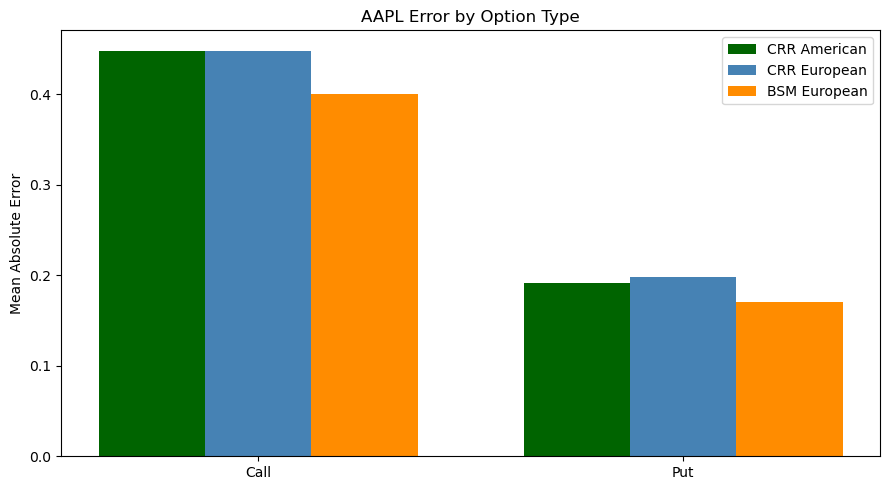

,option_side,crr_american_abs_error,crr_european_abs_error,bsm_european_abs_error
0,call,0.448270,0.448270,0.400004
1,put,0.191999,0.197648,0.170924


In [19]:
error_by_type = (
    validation_results.groupby("option_side")[[
        "crr_american_abs_error",
        "crr_european_abs_error",
        "bsm_european_abs_error",
    ]]
    .mean()
    .reset_index()
)

x = np.arange(len(error_by_type))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, error_by_type["crr_american_abs_error"], width=width, label="CRR American", color="darkgreen")
plt.bar(x, error_by_type["crr_european_abs_error"], width=width, label="CRR European", color="steelblue")
plt.bar(x + width, error_by_type["bsm_european_abs_error"], width=width, label="BSM European", color="darkorange")
plt.xticks(x, error_by_type["option_side"].str.title())
plt.ylabel("Mean Absolute Error")
plt.title(f"{ticker} Error by Option Type")
plt.legend()
plt.tight_layout()

plt.savefig(paths.figures / f"{ticker}_current_market_validation_error_by_type.png", dpi=200, bbox_inches="tight")
plt.show()

error_by_type

## 10. Visualization: Error by Maturity and Strike

Plot the contract-level pricing errors against maturity and strike so the error distribution can be examined more closely.

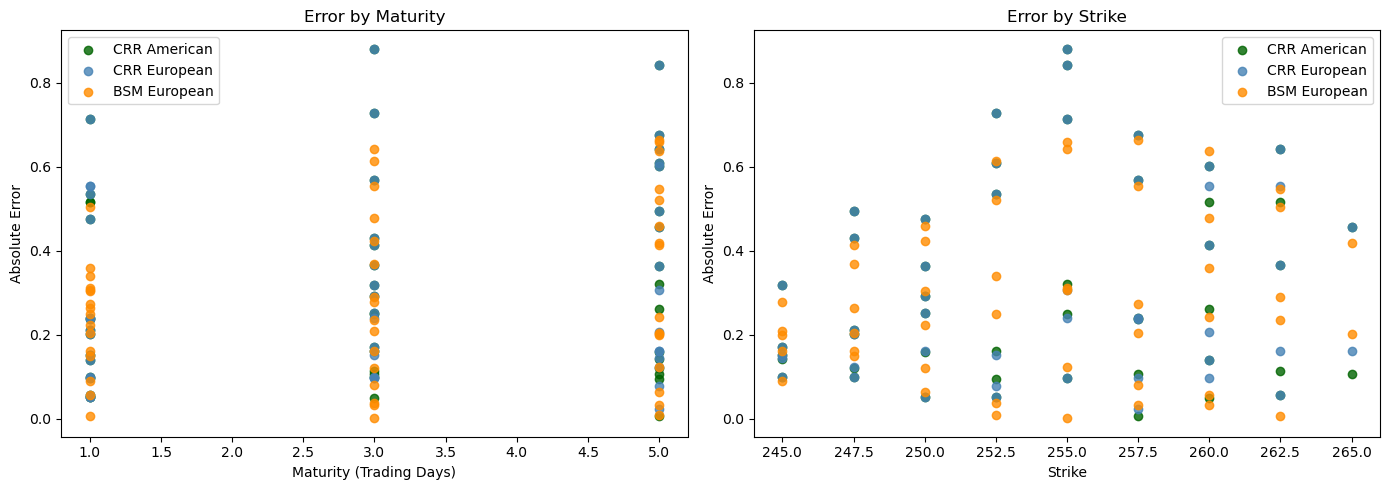

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(validation_results["maturity_days"], validation_results["crr_american_abs_error"], label="CRR American", color="darkgreen", alpha=0.8)
axes[0].scatter(validation_results["maturity_days"], validation_results["crr_european_abs_error"], label="CRR European", color="steelblue", alpha=0.8)
axes[0].scatter(validation_results["maturity_days"], validation_results["bsm_european_abs_error"], label="BSM European", color="darkorange", alpha=0.8)
axes[0].set_xlabel("Maturity (Trading Days)")
axes[0].set_ylabel("Absolute Error")
axes[0].set_title("Error by Maturity")
axes[0].legend()

axes[1].scatter(validation_results["strike"], validation_results["crr_american_abs_error"], label="CRR American", color="darkgreen", alpha=0.8)
axes[1].scatter(validation_results["strike"], validation_results["crr_european_abs_error"], label="CRR European", color="steelblue", alpha=0.8)
axes[1].scatter(validation_results["strike"], validation_results["bsm_european_abs_error"], label="BSM European", color="darkorange", alpha=0.8)
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Absolute Error")
axes[1].set_title("Error by Strike")
axes[1].legend()

plt.tight_layout()
plt.savefig(paths.figures / f"{ticker}_current_market_validation_error_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Interpretation Notes

This notebook evaluates the models against real market option quotes in the current cross section. Because U.S. listed stock options are generally American-style, `CRR American` is the most natural structural model. `CRR European` and `BSM European` are included as European benchmarks so the pricing differences can be compared directly.